# Plant Disease Classification Using EfficientNetB0

## Project Objective
This notebook builds a deep learning system that classifies plant leaf images as healthy or diseased and predicts the exact disease class.

The final model is designed for later integration with a web application where users can upload or capture a plant image and receive a disease prediction.

## Method Summary
- Dataset validation and duplicate checking
- Transfer learning using EfficientNetB0
- Data augmentation for improved robustness
- Two-stage training: classifier head training followed by fine-tuning
- Evaluation using accuracy, F1-score, confusion matrices, and classification reports
- Model export with class labels and metadata for deployment


## 1. Environment Setup and Configuration

This section defines all imports, reproducibility settings, dataset paths, model parameters, and export filenames.


In [7]:
import json
import warnings
import shutil
import zipfile
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import load_img, img_to_array

from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.utils.class_weight import compute_class_weight

from PIL import Image, UnidentifiedImageError


def get_health_status(class_name: str) -> str:
    """Return Healthy only when the class condition is labeled as healthy."""
    if "___" not in class_name:
        return "Diseased"
    _, disease_part = class_name.split("___", 1)
    return "Healthy" if disease_part == "healthy" else "Diseased"


SEED = 42
tf.keras.utils.set_random_seed(SEED)

# Use mixed precision on GPU to reduce memory usage in Colab.
if tf.config.list_physical_devices("GPU"):
    try:
        tf.keras.mixed_precision.set_global_policy("mixed_float16")
        print("Mixed precision enabled: mixed_float16")
    except Exception as exc:
        print(f"Mixed precision not enabled: {exc}")


IMG_SIZE = (160, 160)
BATCH_SIZE = 8
USE_CLASS_WEIGHTS = False

HEAD_EPOCHS = 15
FINE_TUNE_EPOCHS = 10

PROJECT_ROOT = Path("/content/drive/MyDrive/plant_project")
ZIP_PATH = PROJECT_ROOT / "archive.zip"
EXTRACT_PATH = Path("/content/dataset")

TRAIN_DIR = EXTRACT_PATH / "dataset" / "train"
TEST_DIR = EXTRACT_PATH / "dataset" / "test"

MODEL_SAVE_DIR = PROJECT_ROOT
CHECKPOINT_PATH = MODEL_SAVE_DIR / "best_plant_disease_model.keras"

REMOVE_DUPLICATE_TEST_FILES = True

KERAS_MODEL_FILENAME = "plant_disease_efficientnet_model.keras"
MODEL_DISPLAY_NAME = Path(KERAS_MODEL_FILENAME).stem
CLASS_NAMES_FILENAME = "class_names.json"
METADATA_FILENAME = "model_metadata.json"
METRICS_FILENAME = "metrics.json"
TRAINING_HISTORY_FILENAME = "training_history.json"
CLASSIFICATION_REPORT_CSV = "classification_report.csv"
CONFUSION_MATRIX_CSV = "confusion_matrix.csv"
CONFUSION_MATRIX_NORM_CSV = "normalized_confusion_matrix.csv"

TF_DATA_CACHE_DIR = None
SHUFFLE_BUFFER_MAX = 512

print(f"TensorFlow version: {tf.__version__}")
_gpus = tf.config.list_physical_devices("GPU")
for _gpu in _gpus:
    try:
        tf.config.experimental.set_memory_growth(_gpu, True)
    except RuntimeError:
        pass
print(f"GPU devices available: {len(_gpus)}", _gpus if _gpus else "(CPU only)")


Mixed precision enabled: mixed_float16
TensorFlow version: 2.20.0
GPU devices available: 1 [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    print("Not running in Google Colab — skipping drive.mount(). Ensure PROJECT_ROOT and dataset paths exist.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
if not ZIP_PATH.is_file():
    raise FileNotFoundError(
        f"Dataset ZIP not found at {ZIP_PATH}. Update ZIP_PATH or upload the archive file."
    )

if EXTRACT_PATH.exists():
    shutil.rmtree(EXTRACT_PATH)

EXTRACT_PATH.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

if not TRAIN_DIR.is_dir():
    raise FileNotFoundError(f"Training directory not found after extraction: {TRAIN_DIR}")

if not TEST_DIR.is_dir():
    raise FileNotFoundError(f"Test directory not found after extraction: {TEST_DIR}")

print("Dataset extracted successfully.")
print(f"Training directory: {TRAIN_DIR}")
print(f"Test directory: {TEST_DIR}")


Dataset extracted successfully.
Training directory: /content/dataset/dataset/train
Test directory: /content/dataset/dataset/test


## 2. Dataset Extraction and Path Validation

The dataset archive is extracted into a clean directory. The notebook expects the following structure:

```text
dataset/
  dataset/
    train/
      class_1/
      class_2/
      ...
    test/
      class_1/
      class_2/
      ...
```


In [10]:
print(f"Training directory exists: {TRAIN_DIR.is_dir()} — {TRAIN_DIR.resolve()}")
print(f"Test directory exists:     {TEST_DIR.is_dir()} — {TEST_DIR.resolve()}")

if not TRAIN_DIR.is_dir():
    raise FileNotFoundError(f"Training folder not found: {TRAIN_DIR}")

if not TEST_DIR.is_dir():
    raise FileNotFoundError(f"Test folder not found: {TEST_DIR}")


Training directory exists: True — /content/dataset/dataset/train
Test directory exists:     True — /content/dataset/dataset/test


## 3. Data Quality Validation

Before training, the notebook checks for unreadable image files and exact duplicate images between the training and test sets.

Exact train/test duplicates are removed from the test set when enabled, preventing data leakage and producing more reliable evaluation results.


In [6]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def list_image_paths(dataset_root: Path):
    '''All image paths under class subfolders (same extensions as the training pipeline).'''
    root = Path(dataset_root)
    paths = []
    for class_path in sorted(p for p in root.iterdir() if p.is_dir()):
        for fp in class_path.iterdir():
            if fp.is_file() and fp.suffix.lower() in IMAGE_EXTS:
                paths.append(fp)
    return paths

def find_corrupted_images_pil(image_paths):
    '''Return (path, error) tuples for images PIL cannot verify/load. Does not delete files.'''
    bad = []
    for p in image_paths:
        try:
            with Image.open(p) as img:
                img.verify()
            with Image.open(p) as img:
                img.convert("RGB")
                img.load()
        except (OSError, UnidentifiedImageError, ValueError) as e:
            bad.append((p, repr(e)))
        except Image.DecompressionBombError as e:
            bad.append((p, repr(e)))
    return bad

def sha256_file(path, chunk_bytes=1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(chunk_bytes), b""):
            h.update(block)
    return h.hexdigest()

def invert_hash_map(path_list):
    '''hash -> list of paths (identical file bytes may appear more than once).'''
    hmap = {}
    for p in path_list:
        try:
            digest = sha256_file(p)
        except OSError as e:
            print(f"Skipping hash (read error): {p} — {e}")
            continue
        hmap.setdefault(digest, []).append(p)
    return hmap

def _is_strictly_under(path: Path, parent: Path) -> bool:
    """True if path is inside parent (not parent itself)."""
    path = path.resolve()
    parent = parent.resolve()
    try:
        path.relative_to(parent)
    except ValueError:
        return False
    return path != parent

train_image_paths = list_image_paths(TRAIN_DIR)
test_image_paths = list_image_paths(TEST_DIR)

corrupt_train = find_corrupted_images_pil(train_image_paths)
corrupt_test = find_corrupted_images_pil(test_image_paths)

print("=== Corrupted images (PIL) ===")
print(f"Train: {len(corrupt_train)} corrupted")
print(f"Test:  {len(corrupt_test)} corrupted")
if corrupt_train:
    print("Example train:", corrupt_train[0])
if corrupt_test:
    print("Example test:", corrupt_test[0])

train_by_hash = invert_hash_map(train_image_paths)

while True:
    test_image_paths = list_image_paths(TEST_DIR)
    test_by_hash = invert_hash_map(test_image_paths)
    train_hashes = set(train_by_hash.keys())
    test_hashes = set(test_by_hash.keys())
    shared_hashes = train_hashes & test_hashes

    duplicate_test_files = []
    for h in shared_hashes:
        duplicate_test_files.extend(test_by_hash[h])

    print("\n=== Duplicate content (train vs test, SHA-256) ===")
    print(f"SHA-256 hashes shared between train and test: {len(shared_hashes)}")
    n_dup_test = len(duplicate_test_files)
    print(f"Number of duplicate test files (byte-identical to at least one train file): {n_dup_test}")

    if not duplicate_test_files:
        print(
            "\nOK: No train/test SHA-256 duplicates — no test file is an exact byte copy of a training file "
            "(among successfully hashed images). Safe to continue."
        )
        break

    print("\nExample duplicate test paths:")
    for p in duplicate_test_files[:5]:
        print(f"  {p}")
    if n_dup_test > 5:
        print(f"  ... and {n_dup_test - 5} more")

    if REMOVE_DUPLICATE_TEST_FILES:
        removed = 0
        for p in duplicate_test_files:
            p = Path(p)
            if not _is_strictly_under(p, TEST_DIR):
                raise RuntimeError(
                    f"Refusing to delete path outside TEST_DIR: {p} (TEST_DIR={TEST_DIR.resolve()})"
                )
            p.unlink()
            removed += 1
        print(
            f"\nRemoved {removed} duplicate test file(s) under TEST_DIR (same SHA-256 as a training image). "
            "Re-running duplicate check..."
        )
        continue

    raise RuntimeError(
        f"Stopping: {n_dup_test} test image(s) are byte-identical to training images (SHA-256). "
        "Set REMOVE_DUPLICATE_TEST_FILES = True in section 1 to drop only those test copies, "
        "or fix the dataset split manually."
    )


=== Corrupted images (PIL) ===
Train: 0 corrupted
Test:  0 corrupted

=== Duplicate content (train vs test, SHA-256) ===
SHA-256 hashes shared between train and test: 4
Number of duplicate test files (byte-identical to at least one train file): 4

Example duplicate test paths:
  /content/dataset/dataset/test/Tomato___healthy/1af0bfe1-4bcf-4b8b-be66-5d0953eb647e___GH_HL Leaf 482.2.JPG
  /content/dataset/dataset/test/Apple___healthy/3d075f90-7002-4c45-abc0-4f35ee49aa79___RS_HL 6272.JPG
  /content/dataset/dataset/test/Tomato___Late_blight/5f21282c-e2ef-4c4a-ace1-b5701fe7effc___GHLB2 Leaf 8999.JPG
  /content/dataset/dataset/test/Apple___healthy/1ab5e019-e5f0-4d8e-a252-94cb0aab8b0a___RS_HL 6269.JPG

Removed 4 duplicate test file(s) under TEST_DIR (same SHA-256 as a training image). Re-running duplicate check...

=== Duplicate content (train vs test, SHA-256) ===
SHA-256 hashes shared between train and test: 0
Number of duplicate test files (byte-identical to at least one train file): 0

OK:

## 4. Class Distribution

The number of images per class is calculated to identify class imbalance before training.


In [11]:
def count_images_per_class(directory: Path):
    rows = []
    root = Path(directory)
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    for class_path in sorted(p for p in root.iterdir() if p.is_dir()):
        image_files = [f for f in class_path.iterdir() if f.is_file() and f.suffix.lower() in exts]
        rows.append({"class": class_path.name, "count": len(image_files)})
    return pd.DataFrame(rows).sort_values("count", ascending=True)

train_counts = count_images_per_class(TRAIN_DIR)
test_counts = count_images_per_class(TEST_DIR)

print("Training set class distribution:")
try:
    display(train_counts)  # Colab / Jupyter
except NameError:
    print(train_counts.to_string(index=False))

print("\nTest set class distribution:")
try:
    display(test_counts)
except NameError:
    print(test_counts.to_string(index=False))


Training set class distribution:


,class,count
22,Potato___healthy,122
2,Apple___Cedar_apple_rust,220
17,Peach___healthy,288
23,Raspberry___healthy,297
36,Tomato___Tomato_mosaic_virus,299
14,Grape___healthy,339
27,Strawberry___healthy,365
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,411
1,Apple___Black_rot,497
0,Apple___Apple_scab,504



Test set class distribution:


,class,count
22,Potato___healthy,30
2,Apple___Cedar_apple_rust,55
17,Peach___healthy,72
23,Raspberry___healthy,74
36,Tomato___Tomato_mosaic_virus,74
14,Grape___healthy,84
27,Strawberry___healthy,91
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,102
1,Apple___Black_rot,124
0,Apple___Apple_scab,126


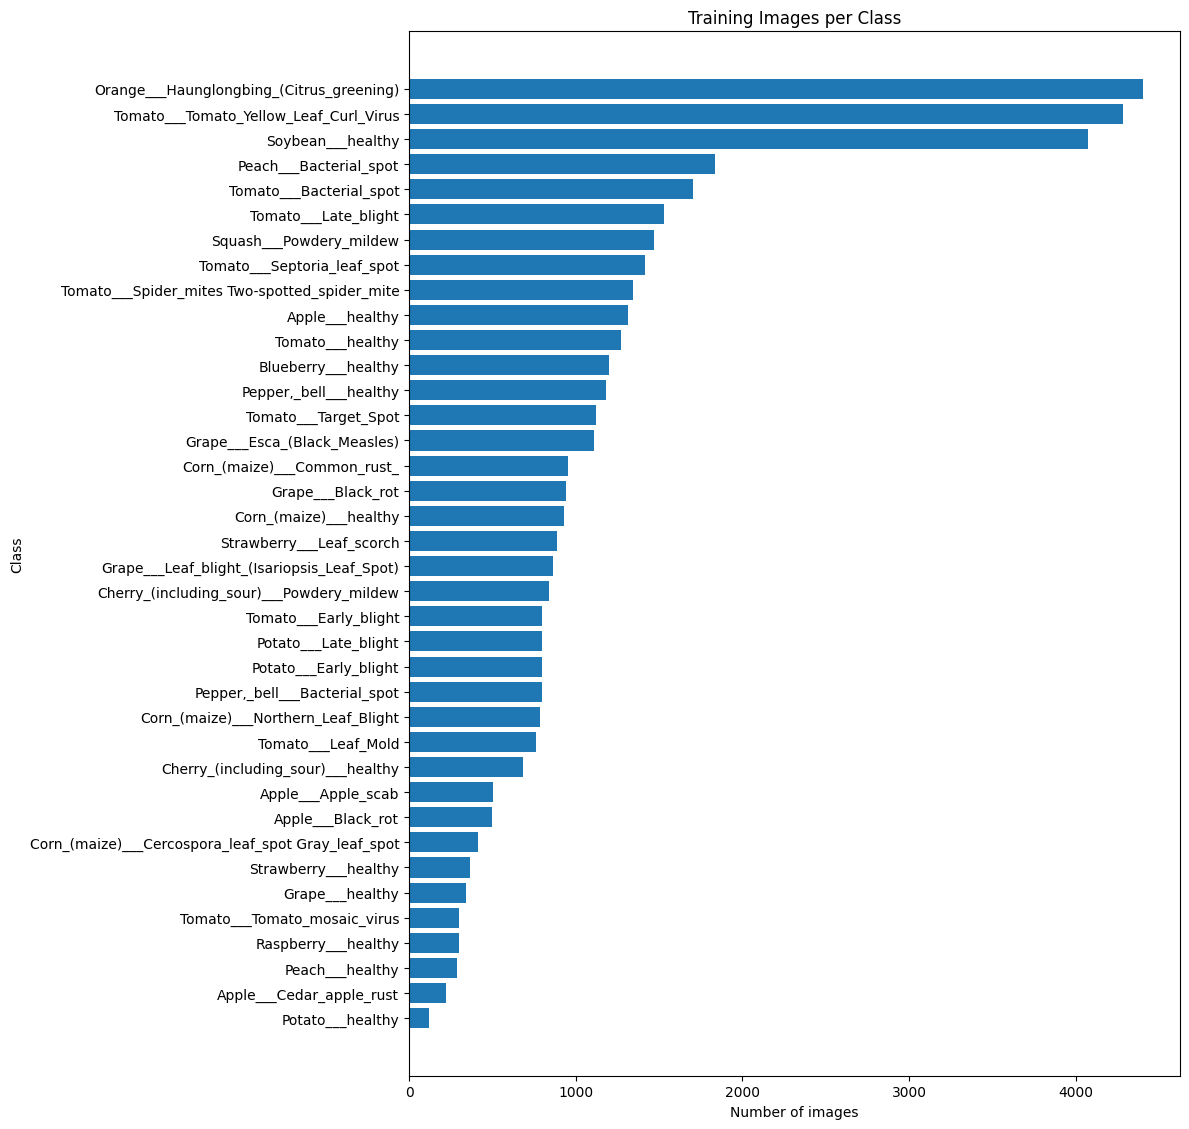

In [12]:
plt.figure(figsize=(12, max(6, len(train_counts) * 0.3)))
plt.barh(train_counts["class"], train_counts["count"])
plt.title("Training Images per Class")
plt.xlabel("Number of images")
plt.ylabel("Class")
plt.tight_layout()
plt.show()


## 5. Dataset Loading

The training directory is split into training and validation subsets. The separate test directory is reserved only for final evaluation.


In [13]:
# Training images are split into train (80%) and validation (20%) with the same seed.
# The separate `test/` folder is never used during fit — no leakage from test into train/val.
train_data = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
)

val_data = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
)

test_data = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False,  # stable order for metrics and confusion matrix
)

class_names = train_data.class_names
num_classes = len(class_names)

# Labels must map to the same string classes on train and test (alphabetical folder order).
if test_data.class_names != class_names:
    raise ValueError(
        "Train and test class_names differ — evaluation labels will be wrong. "
        f"Train ({len(class_names)}): {class_names[:5]}... "
        f"Test ({len(test_data.class_names)}): {test_data.class_names[:5]}..."
    )

print("Number of classes:", num_classes)
print("Classes:")
for i, name in enumerate(class_names):
    print(i, name)


Found 43456 files belonging to 38 classes.
Using 34765 files for training.
Found 43456 files belonging to 38 classes.
Using 8691 files for validation.
Found 10849 files belonging to 38 classes.
Number of classes: 38
Classes:
0 Apple___Apple_scab
1 Apple___Black_rot
2 Apple___Cedar_apple_rust
3 Apple___healthy
4 Blueberry___healthy
5 Cherry_(including_sour)___Powdery_mildew
6 Cherry_(including_sour)___healthy
7 Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8 Corn_(maize)___Common_rust_
9 Corn_(maize)___Northern_Leaf_Blight
10 Corn_(maize)___healthy
11 Grape___Black_rot
12 Grape___Esca_(Black_Measles)
13 Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 Grape___healthy
15 Orange___Haunglongbing_(Citrus_greening)
16 Peach___Bacterial_spot
17 Peach___healthy
18 Pepper,_bell___Bacterial_spot
19 Pepper,_bell___healthy
20 Potato___Early_blight
21 Potato___Late_blight
22 Potato___healthy
23 Raspberry___healthy
24 Soybean___healthy
25 Squash___Powdery_mildew
26 Strawberry___Leaf_scorch
27 Stra

In [14]:
def count_labels_in_tf_dataset(ds, class_names, split_name="split"):
    """Count integer labels by iterating every batch in the dataset (one full pass)."""
    counts = np.zeros(len(class_names), dtype=np.int64)
    n_batches = 0
    for _, labels in ds:
        for lab in labels.numpy().ravel():
            counts[int(lab)] += 1
        n_batches += 1
    print(f"  {split_name}: scanned {n_batches} batch(es), total samples {int(counts.sum())}")
    return {class_names[i]: int(counts[i]) for i in range(len(class_names))}

def label_counts_to_dataframe(count_map):
    """One row per class, sorted by class name."""
    return (
        pd.DataFrame(
            {"class": list(count_map.keys()), "count": list(count_map.values())}
        )
        .sort_values("class", ignore_index=True)
    )

def classes_missing_from_split(count_map):
    """Class names with zero samples in this split."""
    return sorted([name for name, c in count_map.items() if c == 0])

print("Counting labels in TensorFlow datasets (one full pass per split)...\n")
train_label_counts = count_labels_in_tf_dataset(train_data, class_names, "train (tf.data)")
val_label_counts = count_labels_in_tf_dataset(val_data, class_names, "validation (tf.data)")
test_label_counts = count_labels_in_tf_dataset(test_data, class_names, "test (tf.data)")

df_train_labels = label_counts_to_dataframe(train_label_counts)
df_val_labels = label_counts_to_dataframe(val_label_counts)
df_test_labels = label_counts_to_dataframe(test_label_counts)

print("\nActual training split — label counts:")
try:
    display(df_train_labels)
except NameError:
    print(df_train_labels.to_string(index=False))

print("\nActual validation split — label counts:")
try:
    display(df_val_labels)
except NameError:
    print(df_val_labels.to_string(index=False))

print("\nActual test split — label counts:")
try:
    display(df_test_labels)
except NameError:
    print(df_test_labels.to_string(index=False))

missing_train = classes_missing_from_split(train_label_counts)
missing_val = classes_missing_from_split(val_label_counts)
missing_test = classes_missing_from_split(test_label_counts)

if missing_train:
    raise RuntimeError(
        "Training tf.data split has no samples for the following class(es): "
        f"{missing_train}. You cannot train a multi-class head without at least one "
        "example per class in the training subset — add images or change validation_split/SEED."
    )

if missing_test:
    raise RuntimeError(
        "Test tf.data split has no samples for the following class(es): "
        f"{missing_test}. The held-out test set must include every class for a complete "
        "benchmark — fix the test folder or labels before continuing."
    )

if missing_val:
    warnings.warn(
        "Validation tf.data split has no samples for the following class(es): "
        f"{missing_val}. Validation metrics will not reflect those classes (often due to "
        "very small per-class counts under an 80/20 file split). Consider more images per "
        "class, a stratified split, or adjusting validation_split.",
        UserWarning,
        stacklevel=1,
    )

if not missing_val:
    print("\nOK: Every class appears at least once in train, validation, and test tf.data splits.")
else:
    print("\nOK: Every class appears at least once in train and test tf.data splits (see validation warning above).")


Counting labels in TensorFlow datasets (one full pass per split)...

  train (tf.data): scanned 4346 batch(es), total samples 34765
  validation (tf.data): scanned 1087 batch(es), total samples 8691
  test (tf.data): scanned 1357 batch(es), total samples 10849

Actual training split — label counts:


,class,count
0,Apple___Apple_scab,401
1,Apple___Black_rot,398
2,Apple___Cedar_apple_rust,168
3,Apple___healthy,1056
4,Blueberry___healthy,959
5,Cherry_(including_sour)___Powdery_mildew,688
6,Cherry_(including_sour)___healthy,535
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,313
8,Corn_(maize)___Common_rust_,768
9,Corn_(maize)___Northern_Leaf_Blight,625



Actual validation split — label counts:


,class,count
0,Apple___Apple_scab,103
1,Apple___Black_rot,99
2,Apple___Cedar_apple_rust,52
3,Apple___healthy,260
4,Blueberry___healthy,243
5,Cherry_(including_sour)___Powdery_mildew,154
6,Cherry_(including_sour)___healthy,149
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,98
8,Corn_(maize)___Common_rust_,186
9,Corn_(maize)___Northern_Leaf_Blight,163



Actual test split — label counts:


,class,count
0,Apple___Apple_scab,126
1,Apple___Black_rot,124
2,Apple___Cedar_apple_rust,55
3,Apple___healthy,329
4,Blueberry___healthy,300
5,Cherry_(including_sour)___Powdery_mildew,210
6,Cherry_(including_sour)___healthy,170
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,102
8,Corn_(maize)___Common_rust_,238
9,Corn_(maize)___Northern_Leaf_Blight,197



OK: Every class appears at least once in train, validation, and test tf.data splits.


## 6. Class Weights

Class weights can be enabled to reduce the effect of class imbalance during training.


In [15]:
# Uses actual training-split counts from the previous cell (not folder totals).
if USE_CLASS_WEIGHTS:
    y_train_idx = np.concatenate(
        [np.full(train_label_counts[name], i, dtype=np.int32) for i, name in enumerate(class_names)]
    )
    cw_arr = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(len(class_names)),
        y=y_train_idx,
    )
    class_weight_for_fit = {i: float(cw_arr[i]) for i in range(len(class_names))}
    df_class_weights = pd.DataFrame(
        {
            "class_index": list(range(len(class_names))),
            "class_name": class_names,
            "train_count": [train_label_counts[c] for c in class_names],
            "weight": [class_weight_for_fit[i] for i in range(len(class_names))],
        }
    )
    print("Balanced class weights for model.fit (train split only):")
    try:
        display(df_class_weights)
    except NameError:
        print(df_class_weights.to_string(index=False))
else:
    class_weight_for_fit = None
    print("USE_CLASS_WEIGHTS is False: model.fit runs without class_weight.")


USE_CLASS_WEIGHTS is False: model.fit runs without class_weight.


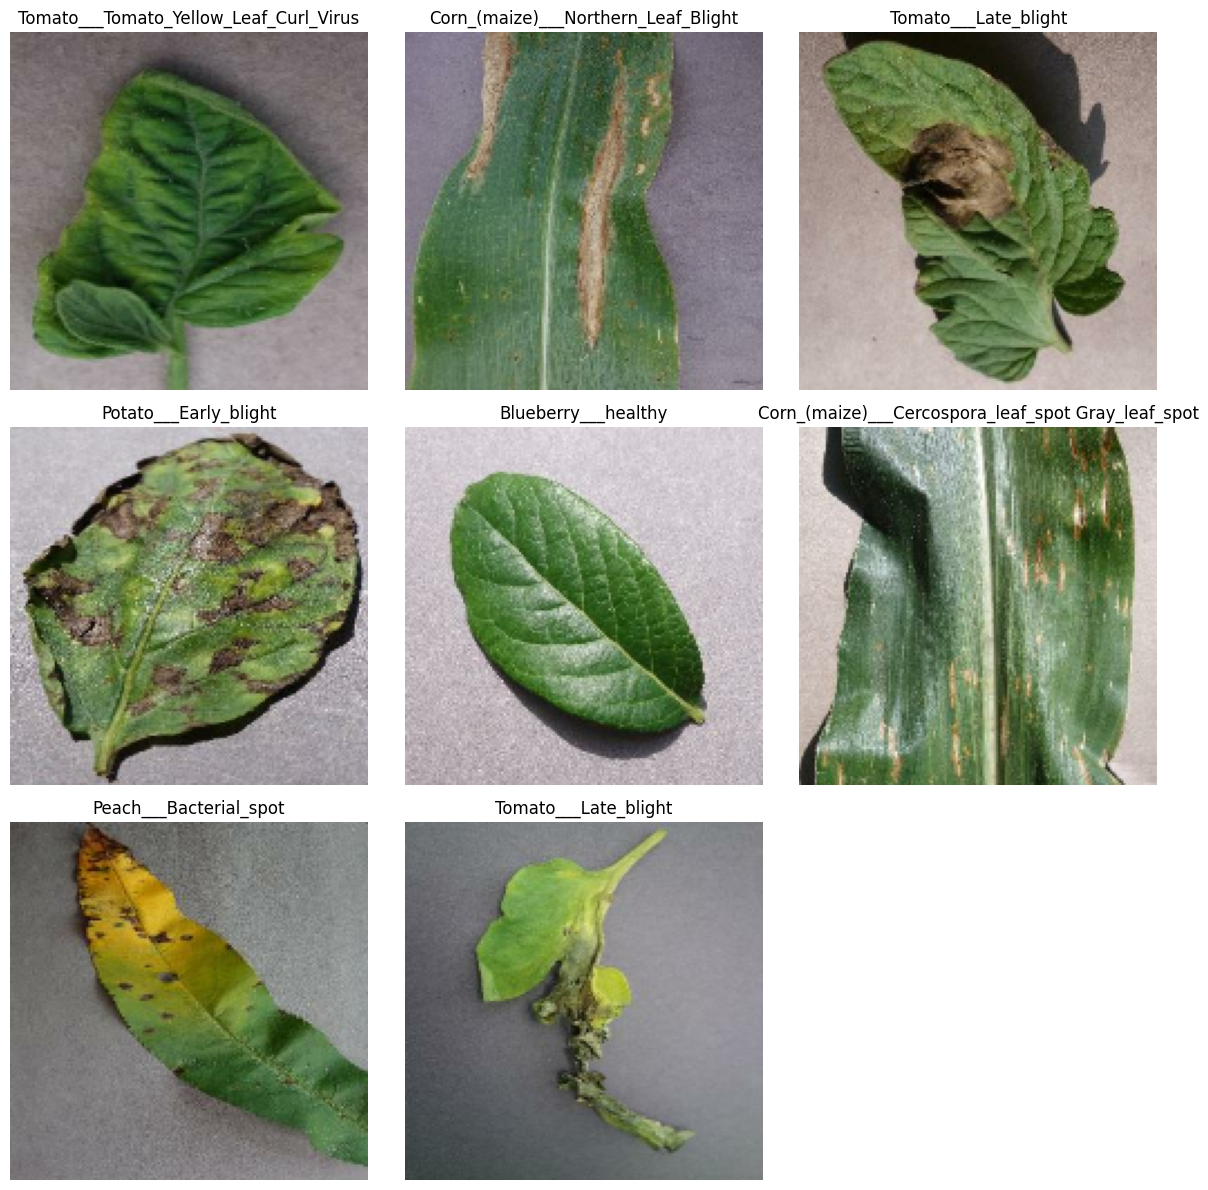

In [16]:
plt.figure(figsize=(12, 12))
for images, labels in train_data.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.tight_layout()
plt.show()


## 7. Data Augmentation and Pipeline Optimization

Moderate augmentation is applied during training to improve robustness to real-world image variation such as rotation, zoom, brightness, and contrast changes.


In [17]:
# Data augmentation is used only while training.
# The transformations are moderate to preserve important disease patterns on the leaf surface.
_aug_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.07),
    layers.RandomZoom(height_factor=(-0.08, 0.08), width_factor=(-0.08, 0.08)),
    layers.RandomTranslation(height_factor=(-0.06, 0.06), width_factor=(-0.06, 0.06)),
    layers.RandomContrast(0.08),
]

_RandomBrightness = getattr(layers, "RandomBrightness", None)
if _RandomBrightness is not None:
    try:
        _aug_layers.append(_RandomBrightness(0.1, value_range=(0.0, 255.0)))
    except TypeError:
        try:
            _aug_layers.append(_RandomBrightness(factor=0.1, value_range=(0.0, 255.0)))
        except Exception as exc:
            print(f"RandomBrightness skipped: {exc}")

data_augmentation = tf.keras.Sequential(_aug_layers, name="data_augmentation")

# Memory-safe input pipeline for Google Colab.
# Cache is disabled to avoid RAM/disk crashes during training.
_card_train = int(tf.data.experimental.cardinality(train_data).numpy())
if _card_train >= 0:
    shuffle_buffer = min(SHUFFLE_BUFFER_MAX, max(_card_train, 1))
else:
    shuffle_buffer = SHUFFLE_BUFFER_MAX

train_data = train_data.shuffle(
    shuffle_buffer,
    seed=SEED,
    reshuffle_each_iteration=True,
).prefetch(buffer_size=1)

val_data = val_data.prefetch(buffer_size=1)
test_data = test_data.prefetch(buffer_size=1)

print(
    f"Data augmentation ready. Memory-safe pipeline enabled: "
    f"batch_size={BATCH_SIZE}, shuffle_buffer={shuffle_buffer}, prefetch=1, cache=disabled"
)


Data augmentation ready. Memory-safe pipeline enabled: batch_size=8, shuffle_buffer=512, prefetch=1, cache=disabled


## 8. EfficientNetB0 Transfer Learning Model

EfficientNetB0 is used as a pretrained feature extractor. The classification head is trained first, then selected upper layers of the base model are fine-tuned.


In [18]:
tf.keras.backend.clear_session()

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE, 3),
)

base_model.trainable = False

# tf.keras.applications.EfficientNetB0 applies the correct ImageNet preprocessing inside the model.
# Do not insert a manual Rescaling layer to [-1, 1] — that would be wrong for this API.
# image_dataset_from_directory yields float32 RGB in [0, 255], which is what this base expects.
model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(shape=(*IMG_SIZE, 3)),
        data_augmentation,
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(num_classes, activation="softmax", dtype="float32"),
    ]
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_accuracy"),
    ],
)

print(f"Model ready. Total parameters: {model.count_params():,}")


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Model ready. Total parameters: 4,223,561


In [19]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1,
)

# Save the best model on the validation set (lowest val_loss). Matches EarlyStopping.
checkpoint = ModelCheckpoint(
    str(CHECKPOINT_PATH),
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1,
)


## 9. Training Stage 1: Classification Head

The EfficientNetB0 base is frozen while the custom classification head is trained.


In [20]:
_fit_class_weight = {}
if USE_CLASS_WEIGHTS:
    _fit_class_weight["class_weight"] = class_weight_for_fit

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=HEAD_EPOCHS,
    callbacks=[early_stop, reduce_lr, checkpoint],
    **_fit_class_weight,
)


Epoch 1/15
4344/4346 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3896 - loss: 2.4910 - top3_accuracy: 0.5527
Epoch 1: val_loss improved from None to 0.56440, saving model to /content/drive/MyDrive/plant_project/best_plant_disease_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/plant_project/best_plant_disease_model.keras
4346/4346 ━━━━━━━━━━━━━━━━━━━━ 152s 30ms/step - accuracy: 0.5399 - loss: 1.7378 - top3_accuracy: 0.7164 - val_accuracy: 0.8366 - val_loss: 0.5644 - val_top3_accuracy: 0.9453 - learning_rate: 1.0000e-04
Epoch 2/15
4346/4346 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7158 - loss: 0.9503 - top3_accuracy: 0.8855
Epoch 2: val_loss improved from 0.56440 to 0.38829, saving model to /content/drive/MyDrive/plant_project/best_plant_disease_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/plant_project/best_plant_disease_model.keras
4346/4346 ━━━━━━━━━━━━━━━━━━━━ 128s 29ms/step - accuracy: 0.7345 - loss: 0.8783 - top3_accuracy: 

## 10. Training Stage 2: Fine-Tuning

The final layers of EfficientNetB0 are unfrozen and trained with a low learning rate to adapt the pretrained features to plant disease images.


In [21]:
base_model.trainable = True

# Freeze early layers; train only the last selected EfficientNet layers (conv weights can adapt to leaves).
for layer in base_model.layers[:-15]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_accuracy"),
    ],
)

_fit_class_weight_ft = {}
if USE_CLASS_WEIGHTS:
    _fit_class_weight_ft["class_weight"] = class_weight_for_fit

fine_tune_history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=[early_stop, reduce_lr, checkpoint],
    **_fit_class_weight_ft,
)


Epoch 1/10
4344/4346 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8667 - loss: 0.4067 - top3_accuracy: 0.9690
Epoch 1: val_loss improved from 0.19756 to 0.18174, saving model to /content/drive/MyDrive/plant_project/best_plant_disease_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/plant_project/best_plant_disease_model.keras
4346/4346 ━━━━━━━━━━━━━━━━━━━━ 153s 32ms/step - accuracy: 0.8703 - loss: 0.3993 - top3_accuracy: 0.9707 - val_accuracy: 0.9392 - val_loss: 0.1817 - val_top3_accuracy: 0.9917 - learning_rate: 1.0000e-05
Epoch 2/10
4345/4346 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8778 - loss: 0.3869 - top3_accuracy: 0.9734
Epoch 2: val_loss improved from 0.18174 to 0.17170, saving model to /content/drive/MyDrive/plant_project/best_plant_disease_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/plant_project/best_plant_disease_model.keras
4346/4346 ━━━━━━━━━━━━━━━━━━━━ 139s 31ms/step - accuracy: 0.8797 - loss: 0.3741 - top3_accurac

## 11. Test Evaluation

The best validation checkpoint is loaded and evaluated on the held-out test set.


In [22]:
# Load the best validation weights from disk so test numbers match the saved checkpoint
# (not merely the last epoch in memory).
print("Loading best validation model from checkpoint...")
best_model = tf.keras.models.load_model(str(CHECKPOINT_PATH))

test_metrics = best_model.evaluate(test_data, verbose=1, return_dict=True)
print(f"Test loss: {test_metrics.get('loss', float('nan')):.4f}")
if "accuracy" in test_metrics:
    print(f"Test accuracy: {test_metrics['accuracy']:.4f}")
if "top3_accuracy" in test_metrics:
    print(f"Test top-3 accuracy: {test_metrics['top3_accuracy']:.4f}")


Loading best validation model from checkpoint...
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 33s 20ms/step - accuracy: 0.9581 - loss: 0.1237 - top3_accuracy: 0.9953
Test loss: 0.1237
Test accuracy: 0.9581
Test top-3 accuracy: 0.9953


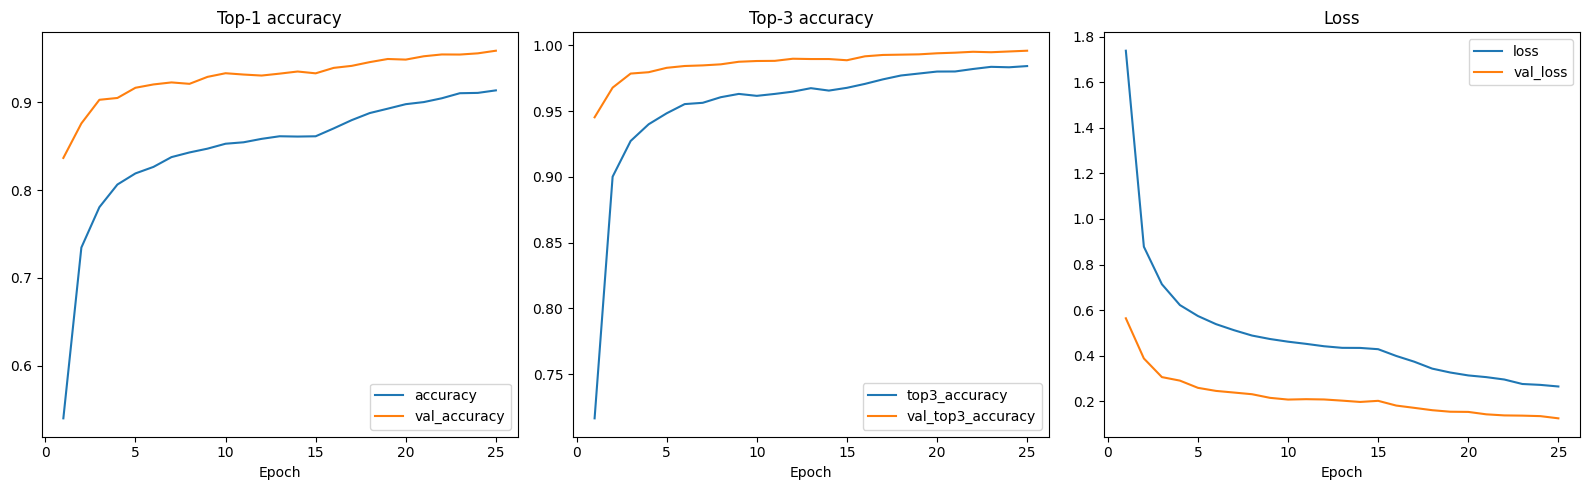

In [23]:
def combine_histories(*histories):
    combined = {}
    for h in histories:
        if h is None:
            continue
        for key, values in h.history.items():
            combined.setdefault(key, []).extend(values)
    return combined

combined_history = combine_histories(history, fine_tune_history)

def _plot_metric_pair(ax, history_dict, train_key, val_key, title):
    """Plot train/val series if present; tolerate missing keys or length mismatch."""
    y_train = history_dict.get(train_key) or []
    y_val = history_dict.get(val_key) or []
    plotted = False
    if y_train:
        ax.plot(range(1, len(y_train) + 1), y_train, label=train_key)
        plotted = True
    if y_val:
        ax.plot(range(1, len(y_val) + 1), y_val, label=val_key)
        plotted = True
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    if plotted:
        ax.legend()
    else:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
_plot_metric_pair(axes[0], combined_history, "accuracy", "val_accuracy", "Top-1 accuracy")
_plot_metric_pair(
    axes[1], combined_history, "top3_accuracy", "val_top3_accuracy", "Top-3 accuracy"
)
_plot_metric_pair(axes[2], combined_history, "loss", "val_loss", "Loss")
plt.tight_layout()
plt.show()

# Diagnose fit: large train–val gap in accuracy + rising val loss often indicates overfitting.
# If train and val track closely but both stay low, consider more data, stronger aug, or longer head training.


## 12. Confusion Matrix and Classification Report

This section reports final class-level performance on the test set using confusion matrices, accuracy, precision, recall, and F1-score.


1357/1357 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step
Test metrics (sklearn):
  Macro F1:        0.9442
  Weighted F1:     0.9570
  Balanced acc:    0.9396


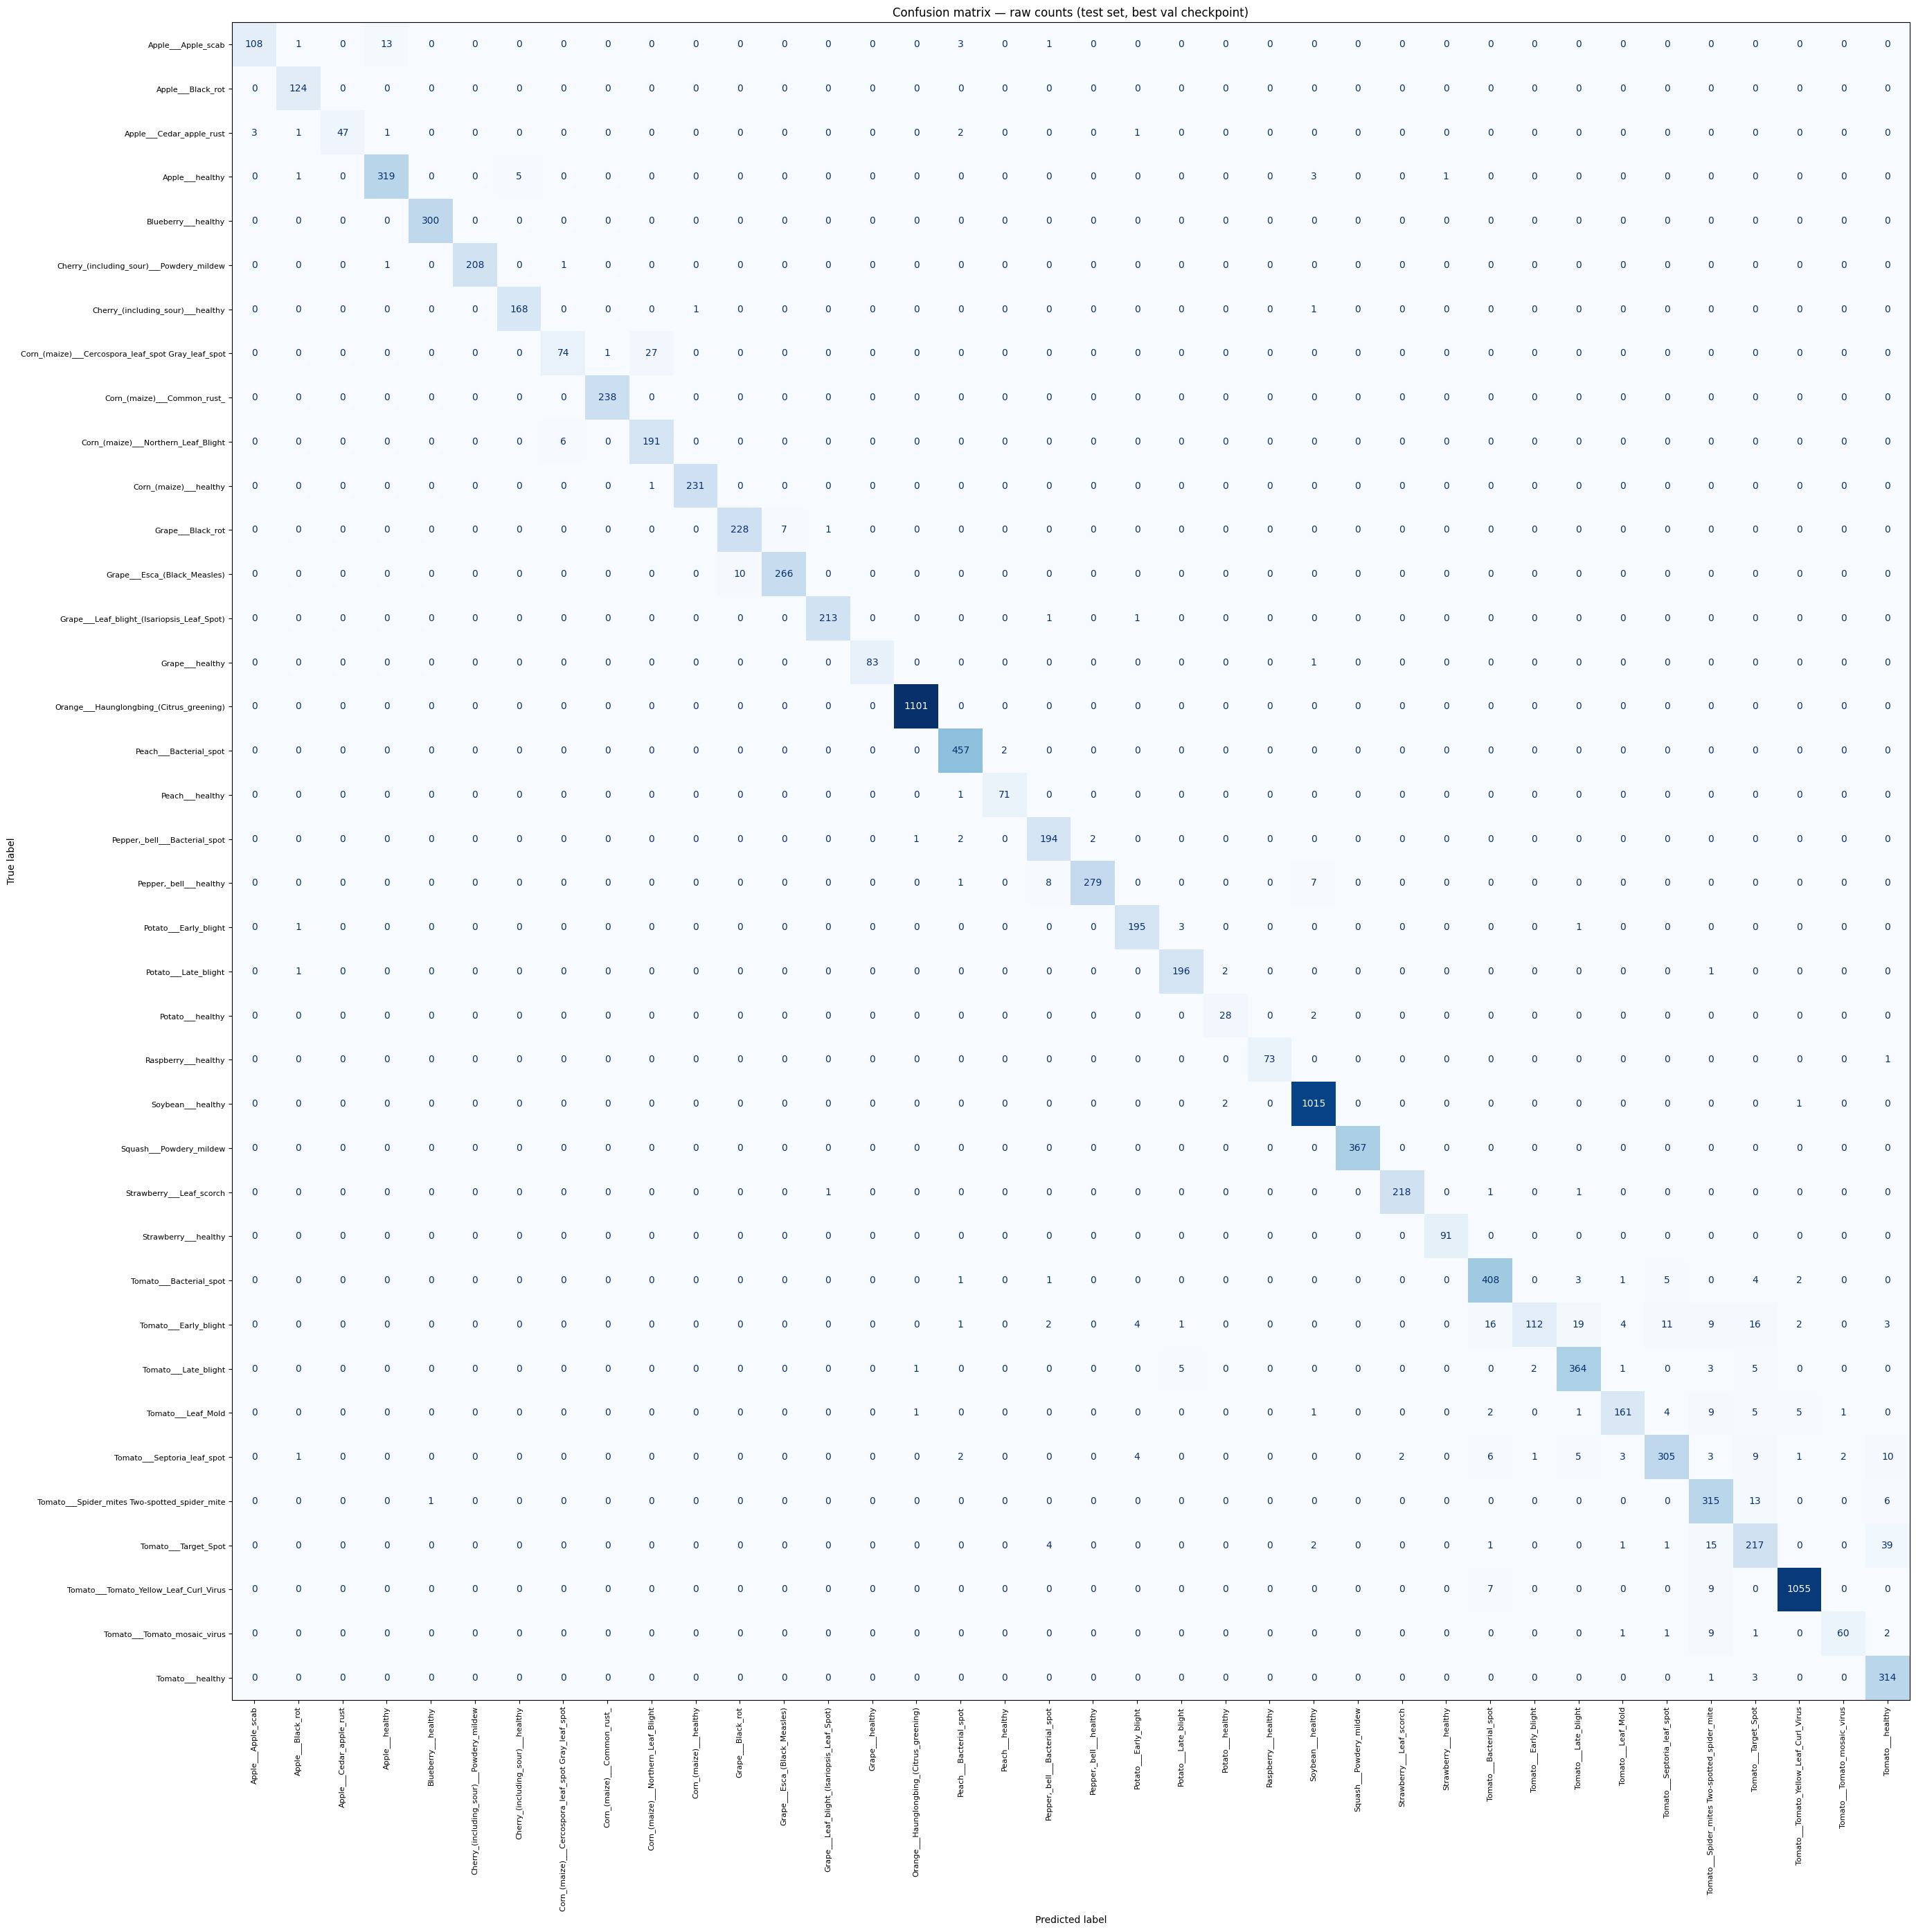

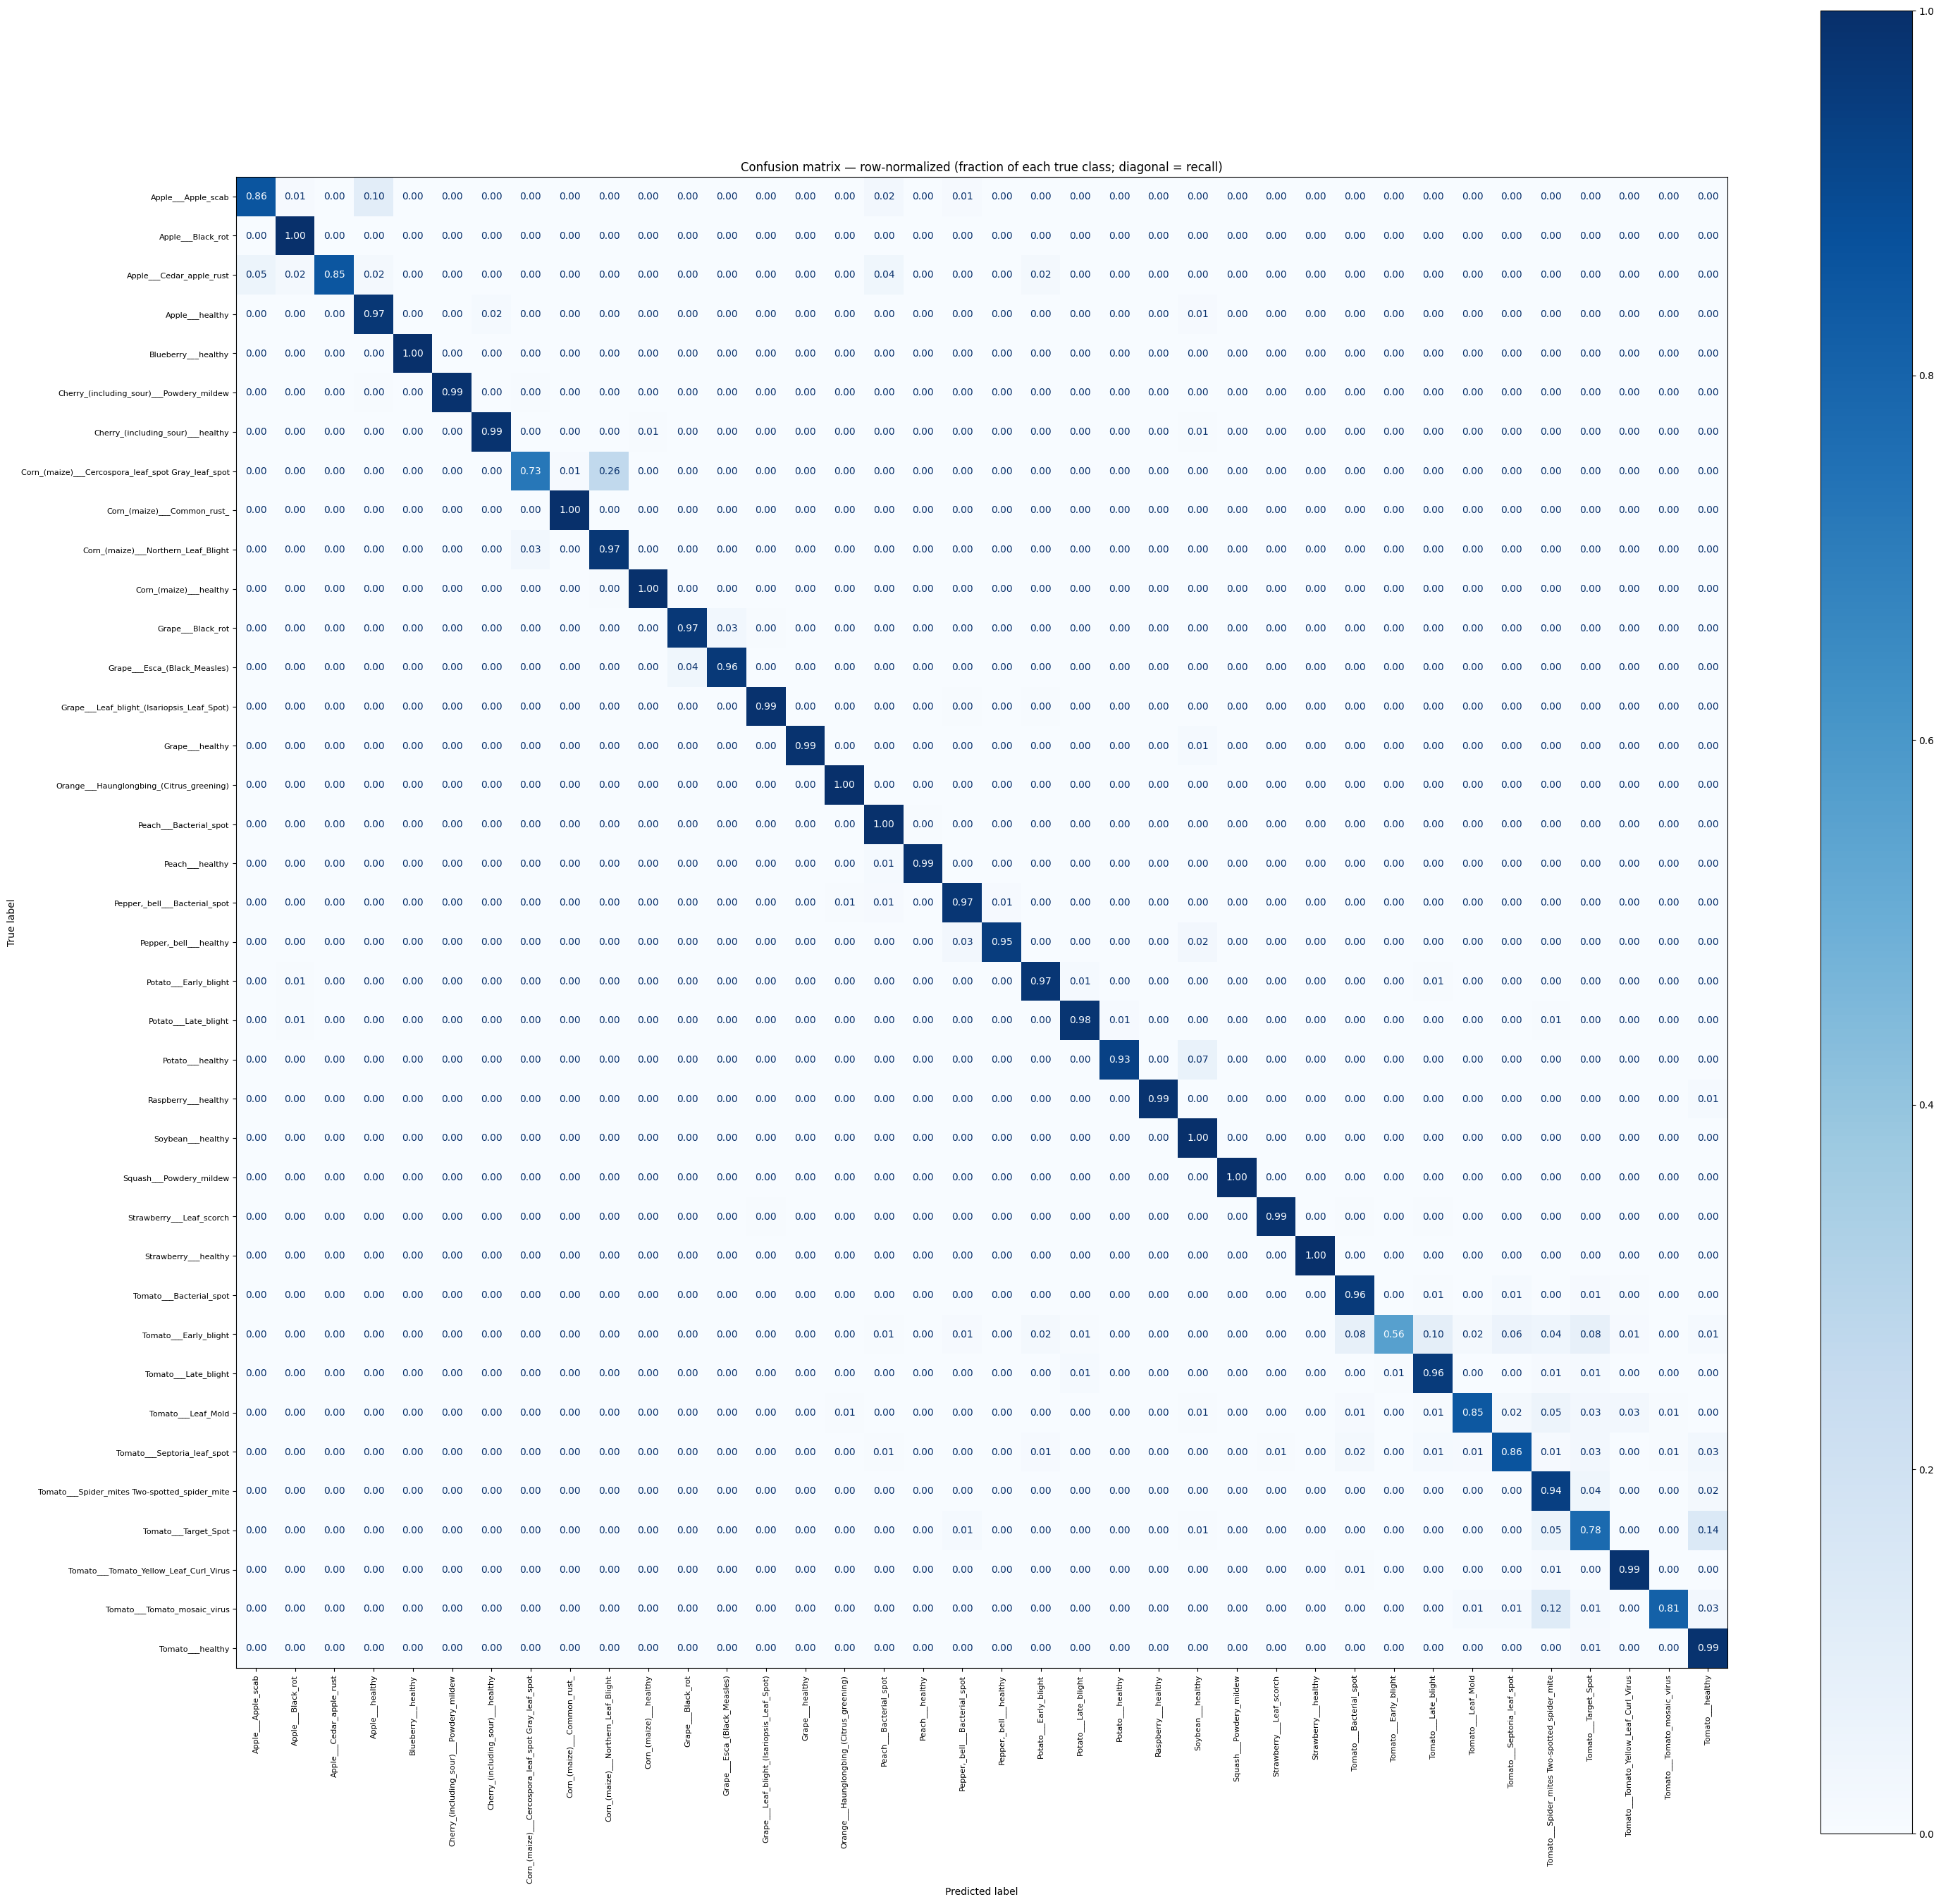

In [24]:
# Final test evaluation: use this held-out set only once for the report below.
# Do not tune hyperparameters using test results and re-train — that leaks test information.

y_true = np.concatenate([labels.numpy() for _, labels in test_data], axis=0).astype(int)
y_pred_probs = best_model.predict(test_data, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)
bal_acc = balanced_accuracy_score(y_true, y_pred)
print("Test metrics (sklearn):")
print(f"  Macro F1:        {f1_macro:.4f}")
print(f"  Weighted F1:     {f1_weighted:.4f}")
print(f"  Balanced acc:    {bal_acc:.4f}")

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(30, 28))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=90, cmap="Blues", values_format="d", colorbar=False)
plt.setp(ax.get_xticklabels(), rotation=90, ha="center", fontsize=8)
plt.setp(ax.get_yticklabels(), fontsize=8)
ax.set_xlabel("Predicted label", fontsize=10)
ax.set_ylabel("True label", fontsize=10)
plt.title("Confusion matrix — raw counts (test set, best val checkpoint)", fontsize=12)
plt.tight_layout()
plt.show()

cm_norm = confusion_matrix(y_true, y_pred, normalize="true")

fig2, ax2 = plt.subplots(figsize=(30, 28))
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp_norm.plot(
    ax=ax2,
    xticks_rotation=90,
    cmap="Blues",
    values_format=".2f",
    colorbar=True,
)
plt.setp(ax2.get_xticklabels(), rotation=90, ha="center", fontsize=8)
plt.setp(ax2.get_yticklabels(), fontsize=8)
ax2.set_xlabel("Predicted label", fontsize=10)
ax2.set_ylabel("True label", fontsize=10)
plt.title(
    "Confusion matrix — row-normalized (fraction of each true class; diagonal = recall)",
    fontsize=12,
)
plt.tight_layout()
plt.show()


In [25]:
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

_acc = report_dict.pop("accuracy", None)
df_classification = pd.DataFrame.from_dict(
    {k: v for k, v in report_dict.items() if isinstance(v, dict)},
    orient="index",
)
df_classification.index.name = "class"
if _acc is not None:
    print(f"Overall accuracy (from report): {_acc:.4f}")
print("\nClassification report (per-class + averages) as DataFrame:")
try:
    display(df_classification)
except NameError:
    print(df_classification.to_string())

_class_rows = df_classification.loc[df_classification.index.isin(class_names)]
df_worst_f1 = _class_rows.nsmallest(10, "f1-score").reset_index()
print("\n10 worst classes by F1-score (ascending):")
try:
    display(df_worst_f1)
except NameError:
    print(df_worst_f1.to_string(index=False))


Overall accuracy (from report): 0.9581

Classification report (per-class + averages) as DataFrame:


,precision,recall,f1-score,support
class,,,,
Apple___Apple_scab,0.972973,0.857143,0.911392,126.0
Apple___Black_rot,0.953846,1.000000,0.976378,124.0
Apple___Cedar_apple_rust,1.000000,0.854545,0.921569,55.0
Apple___healthy,0.955090,0.969605,0.962293,329.0
Blueberry___healthy,0.996678,1.000000,0.998336,300.0
Cherry_(including_sour)___Powdery_mildew,1.000000,0.990476,0.995215,210.0
Cherry_(including_sour)___healthy,0.971098,0.988235,0.979592,170.0
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,0.913580,0.725490,0.808743,102.0
Corn_(maize)___Common_rust_,0.995816,1.000000,0.997904,238.0



10 worst classes by F1-score (ascending):


,class,precision,recall,f1-score,support
0,Tomato___Early_blight,0.973913,0.560000,0.711111,200.0
1,Tomato___Target_Spot,0.794872,0.775000,0.784810,280.0
2,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,0.913580,0.725490,0.808743,102.0
3,Tomato___Tomato_mosaic_virus,0.952381,0.810811,0.875912,74.0
4,Tomato___Spider_mites Two-spotted_spider_mite,0.842246,0.940299,0.888575,335.0
5,Tomato___Leaf_Mold,0.936047,0.847368,0.889503,190.0
6,Tomato___Septoria_leaf_spot,0.932722,0.861582,0.895742,354.0
7,Potato___healthy,0.875000,0.933333,0.903226,30.0
8,Tomato___healthy,0.837333,0.987421,0.906205,318.0
9,Apple___Apple_scab,0.972973,0.857143,0.911392,126.0


## 13. Healthy vs Diseased Evaluation

In addition to exact class prediction, the model is evaluated on the binary task of distinguishing healthy leaves from diseased leaves.


Healthy vs Diseased — classification report (test set):
              precision    recall  f1-score   support

     Healthy       0.97      0.99      0.98      3013
    Diseased       1.00      0.99      0.99      7836

    accuracy                           0.99     10849
   macro avg       0.99      0.99      0.99     10849
weighted avg       0.99      0.99      0.99     10849



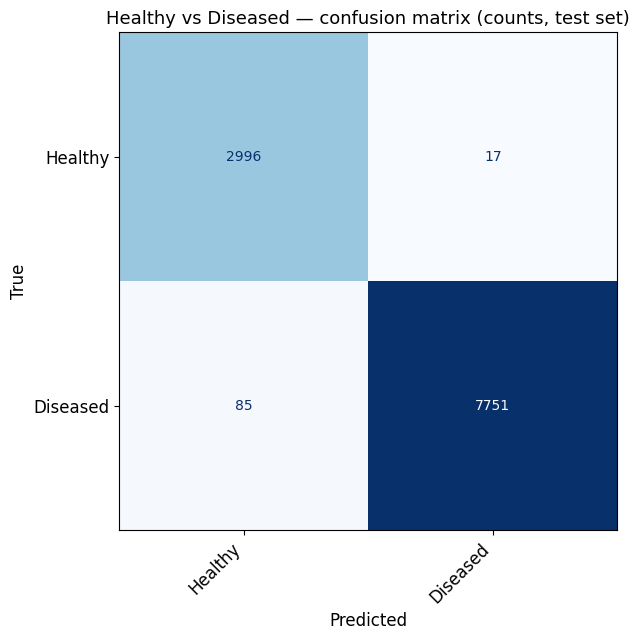

In [26]:
bin_labels = ["Healthy", "Diseased"]
y_true_hvd = np.array([get_health_status(class_names[i]) for i in y_true])
y_pred_hvd = np.array([get_health_status(class_names[i]) for i in y_pred])

print("Healthy vs Diseased — classification report (test set):")
print(
    classification_report(
        y_true_hvd,
        y_pred_hvd,
        labels=bin_labels,
        target_names=bin_labels,
        zero_division=0,
    )
)

cm_hvd = confusion_matrix(y_true_hvd, y_pred_hvd, labels=bin_labels)
fig_hvd, ax_hvd = plt.subplots(figsize=(8, 6.5))
disp_hvd = ConfusionMatrixDisplay(confusion_matrix=cm_hvd, display_labels=bin_labels)
disp_hvd.plot(ax=ax_hvd, cmap="Blues", values_format="d", colorbar=False)
plt.setp(ax_hvd.get_xticklabels(), rotation=45, ha="right", fontsize=12)
plt.setp(ax_hvd.get_yticklabels(), fontsize=12)
ax_hvd.set_xlabel("Predicted", fontsize=12)
ax_hvd.set_ylabel("True", fontsize=12)
plt.title("Healthy vs Diseased — confusion matrix (counts, test set)", fontsize=13)
plt.tight_layout()
plt.show()


## 14. Confidence Analysis

The model confidence score is analyzed to support responsible interpretation of predictions and identify uncertain outputs.


Confidence summary (max softmax per image, test set):
  Mean confidence when correct:   0.9708
  Median confidence when correct: 0.9999
  Mean confidence when wrong:     0.6711
  Median confidence when wrong:   0.6728

Top 20 wrong predictions with highest confidence (of 455 errors):


,confidence,correct,true_class,predicted_class
7819,0.999654,False,Tomato___Early_blight,Tomato___Late_blight
108,0.998111,False,Apple___Apple_scab,Apple___healthy
1322,0.997238,False,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,Corn_(maize)___Northern_Leaf_Blight
4542,0.992755,False,"Pepper,_bell___Bacterial_spot",Peach___Bacterial_spot
1360,0.990578,False,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,Corn_(maize)___Northern_Leaf_Blight
1403,0.988996,False,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,Corn_(maize)___Northern_Leaf_Blight
1346,0.988825,False,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,Corn_(maize)___Northern_Leaf_Blight
8656,0.985125,False,Tomato___Septoria_leaf_spot,Tomato___Late_blight
1399,0.984821,False,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,Corn_(maize)___Northern_Leaf_Blight
1355,0.984012,False,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,Corn_(maize)___Northern_Leaf_Blight


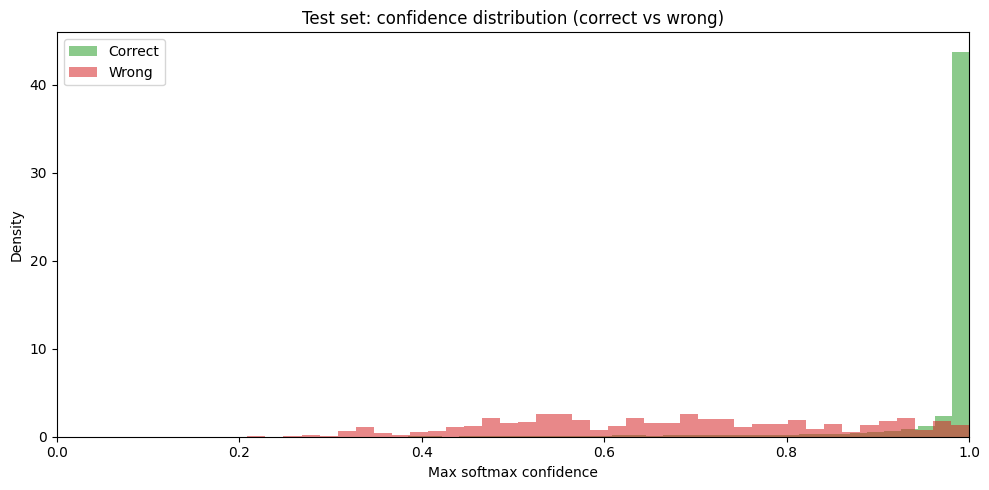

In [27]:
_max_conf = np.max(y_pred_probs, axis=1)
_correct = y_pred == y_true

df_confidence = pd.DataFrame(
    {
        "confidence": _max_conf,
        "correct": _correct,
        "true_class": [class_names[i] for i in y_true],
        "predicted_class": [class_names[i] for i in y_pred],
    }
)

_mask_ok = df_confidence["correct"]
_n_wrong = int((~_mask_ok).sum())
print("Confidence summary (max softmax per image, test set):")
if _mask_ok.any():
    print(f"  Mean confidence when correct:   {df_confidence.loc[_mask_ok, 'confidence'].mean():.4f}")
    print(f"  Median confidence when correct: {df_confidence.loc[_mask_ok, 'confidence'].median():.4f}")
else:
    print("  No correct predictions — mean/median for correct N/A.")
if (~_mask_ok).any():
    print(f"  Mean confidence when wrong:     {df_confidence.loc[~_mask_ok, 'confidence'].mean():.4f}")
    print(f"  Median confidence when wrong:   {df_confidence.loc[~_mask_ok, 'confidence'].median():.4f}")
else:
    print("  No wrong predictions — mean/median for wrong N/A.")

print(f"\nTop 20 wrong predictions with highest confidence (of {_n_wrong} errors):")
if _n_wrong > 0:
    _wrong_top20 = df_confidence.loc[~_mask_ok].nlargest(20, "confidence")
    try:
        display(_wrong_top20)
    except NameError:
        print(_wrong_top20.to_string(index=False))
else:
    print("  (none)")

fig_c, ax_c = plt.subplots(figsize=(10, 5))
if _mask_ok.any():
    ax_c.hist(
        df_confidence.loc[_mask_ok, "confidence"],
        bins=40,
        alpha=0.55,
        label="Correct",
        density=True,
        color="tab:green",
    )
if (~_mask_ok).any():
    ax_c.hist(
        df_confidence.loc[~_mask_ok, "confidence"],
        bins=40,
        alpha=0.55,
        label="Wrong",
        density=True,
        color="tab:red",
    )
ax_c.set_xlabel("Max softmax confidence")
ax_c.set_ylabel("Density")
ax_c.set_title("Test set: confidence distribution (correct vs wrong)")
ax_c.legend()
ax_c.set_xlim(0.0, 1.0)
plt.tight_layout()
plt.show()


## 15. Prediction Visualization

Sample test predictions are displayed with true labels, predicted labels, and confidence values.


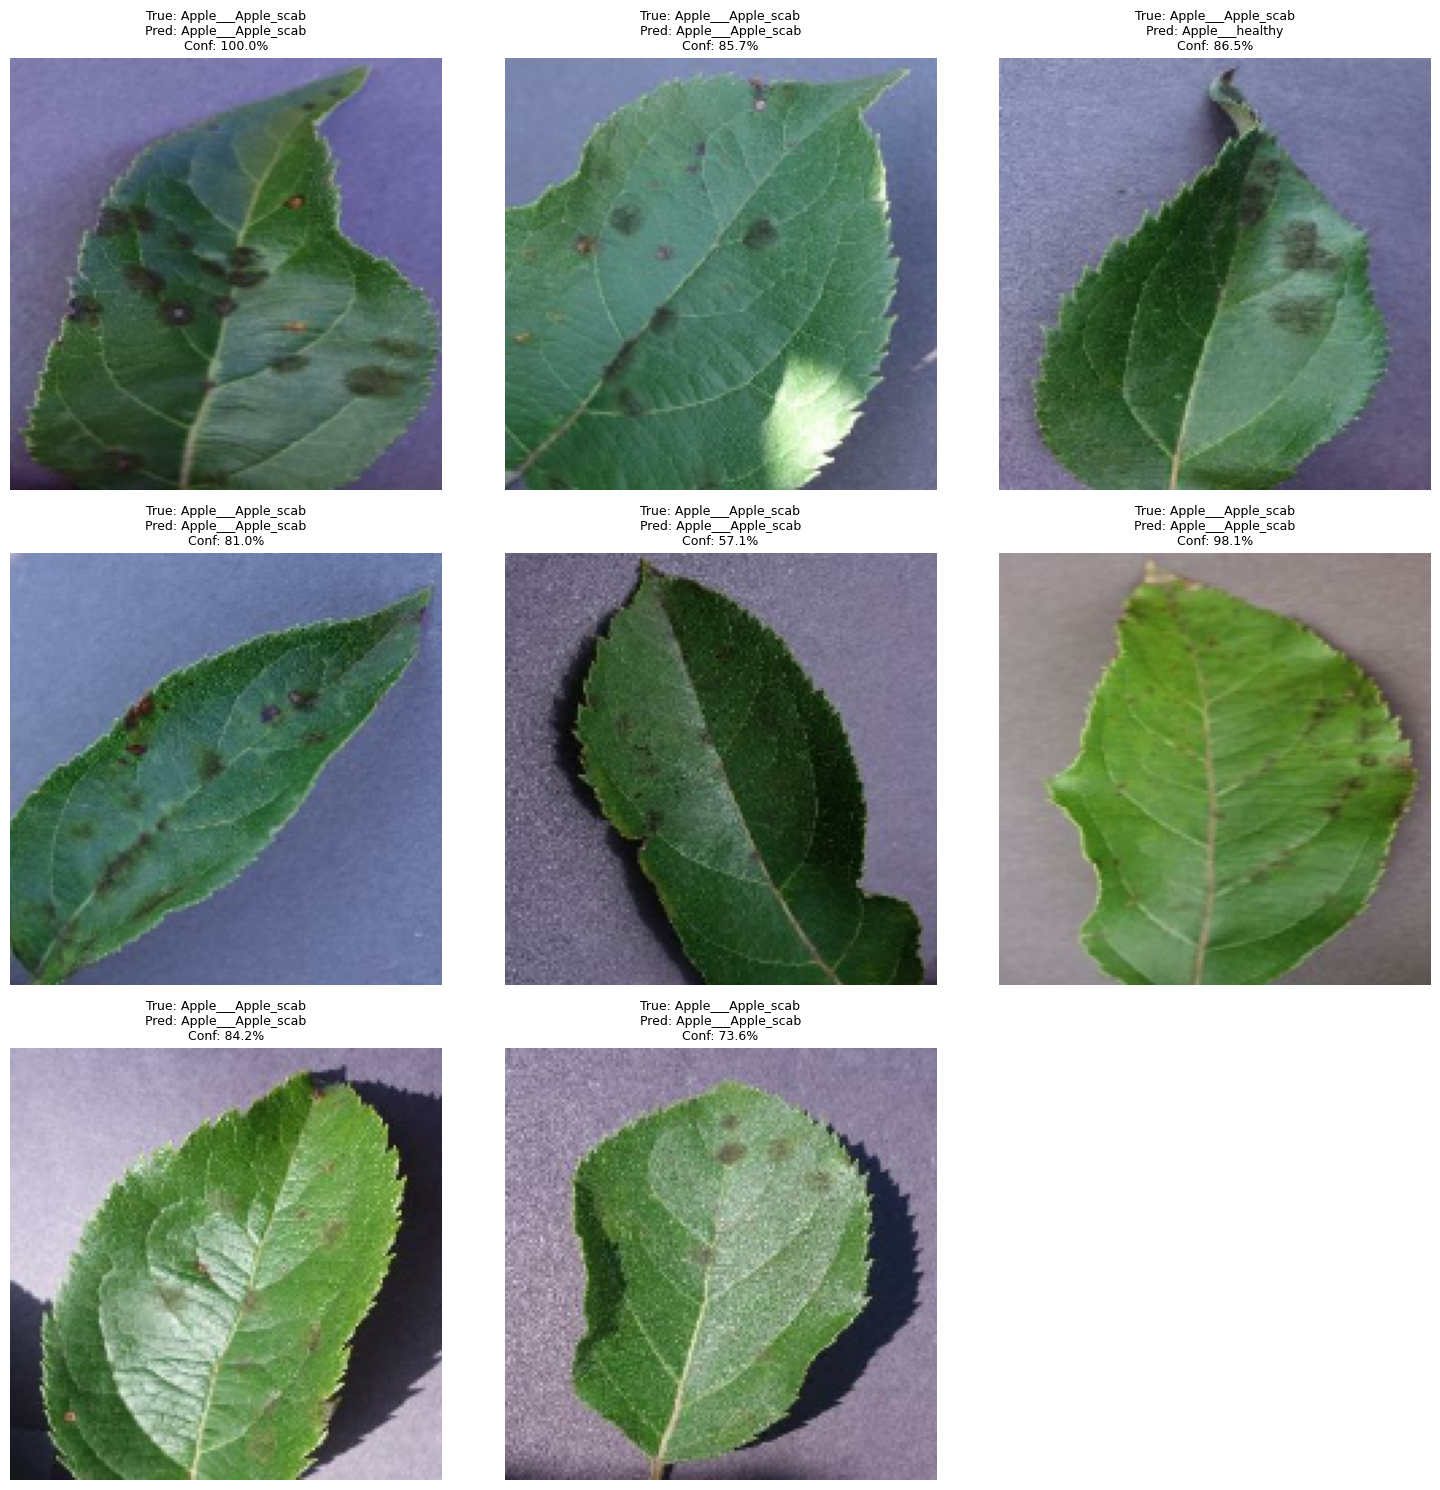

In [28]:
plt.figure(figsize=(15, 15))

for images, labels in test_data.take(1):
    preds = best_model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)

    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        true_label = class_names[int(labels[i])]
        predicted_label = class_names[int(pred_labels[i])]
        confidence = np.max(preds[i]) * 100

        title = f"True: {true_label}\nPred: {predicted_label}\nConf: {confidence:.1f}%"
        plt.title(title, fontsize=9)
        plt.axis("off")

plt.tight_layout()
plt.show()


## 16. Single-Image Prediction Function

The helper function below predicts the class of a single image and returns the health status, confidence score, and top-k predictions.


In [29]:
def predict_image(
    image_path,
    model,
    class_names,
    top_k=3,
    min_confidence=60.0,
    show_plot=True,
):
    """
    Returns dict with:
      - status: 'Healthy', 'Diseased', or 'Uncertain' (if top-1 confidence < min_confidence)
      - predicted_class: top-1 class name
      - confidence: top-1 softmax probability in percent [0, 100]
      - top_k: list of {rank, predicted_class, confidence, status} using get_health_status per class
    """
    p = Path(image_path)
    if not p.exists():
        raise FileNotFoundError(f"Image path does not exist: {p.resolve()}")
    if not p.is_file():
        raise ValueError(
            f"Path is not a regular file (e.g. directory or device): {p.resolve()}"
        )

    if top_k < 1:
        raise ValueError(f"top_k must be >= 1, got {top_k!r}.")

    _out = model.output_shape
    if _out is None:
        raise ValueError(
            "model.output_shape is None — build or load the model before predict_image."
        )
    _n_out = _out[-1]
    if _n_out is None:
        raise ValueError(
            f"Cannot validate class count: last dim of output_shape is None (full shape: {_out})."
        )
    if int(_n_out) != len(class_names):
        raise ValueError(
            f"Model output size ({int(_n_out)}) != len(class_names) ({len(class_names)}). "
            "Use the class list from training or class_names.json for this checkpoint."
        )

    try:
        img = load_img(p, target_size=IMG_SIZE)
    except Exception as e:
        raise ValueError(
            f"Could not load image (unsupported format or corrupt file): {p.resolve()}"
        ) from e

    img_array = np.expand_dims(img_to_array(img), axis=0)

    probs = model.predict(img_array, verbose=0)[0]
    if len(probs) != len(class_names):
        raise ValueError(
            f"Prediction vector length ({len(probs)}) != len(class_names) ({len(class_names)})."
        )

    k = min(top_k, len(class_names))
    order = np.argsort(probs)[-k:][::-1]

    predicted_index = int(order[0])
    predicted_class = class_names[predicted_index]
    confidence = float(probs[predicted_index] * 100)

    if confidence < float(min_confidence):
        status = "Uncertain"
    else:
        status = get_health_status(predicted_class)

    top_k_list = []
    for rank, idx in enumerate(order, start=1):
        cname = class_names[int(idx)]
        top_k_list.append(
            {
                "rank": rank,
                "predicted_class": cname,
                "confidence": float(probs[idx] * 100),
                "status": get_health_status(cname),
            }
        )

    if show_plot:
        plt.imshow(img)
        plot_title = (
            f"Status: {status}\nClass: {predicted_class}\n"
            f"Confidence: {confidence:.2f}% (min for label: {float(min_confidence):.1f}%)"
        )
        plt.title(plot_title)
        plt.axis("off")
        plt.show()

    return {
        "status": status,
        "predicted_class": predicted_class,
        "confidence": confidence,
        "top_k": top_k_list,
    }

# Example (uncomment): pass best_model after training
# result = predict_image("/content/sample_leaf.jpg", best_model, class_names)
# print(result)


## 17. Export Model and Evaluation Artifacts

The best model, class names, metadata, metrics, training history, classification report, and confusion matrices are saved for reporting and deployment.


In [30]:
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

keras_model_path = MODEL_SAVE_DIR / KERAS_MODEL_FILENAME
class_names_path = MODEL_SAVE_DIR / CLASS_NAMES_FILENAME
metadata_path = MODEL_SAVE_DIR / METADATA_FILENAME
metrics_json_path = MODEL_SAVE_DIR / METRICS_FILENAME
training_history_json_path = MODEL_SAVE_DIR / TRAINING_HISTORY_FILENAME
classification_report_csv_path = MODEL_SAVE_DIR / CLASSIFICATION_REPORT_CSV
confusion_matrix_csv_path = MODEL_SAVE_DIR / CONFUSION_MATRIX_CSV
normalized_confusion_matrix_csv_path = MODEL_SAVE_DIR / CONFUSION_MATRIX_NORM_CSV

def _to_json_scalar(x):
    """Convert NumPy / TF scalars to plain Python for json.dump."""
    if isinstance(x, np.generic):
        return x.item()
    if isinstance(x, (float, int, str, bool)) or x is None:
        return x
    return x

# Final deliverable: best validation model (same as checkpoint on disk).
best_model.save(keras_model_path)

with open(class_names_path, "w", encoding="utf-8") as f:
    json.dump(class_names, f, indent=2)

metadata = {
    "backbone": "EfficientNetB0",
    "num_classes": int(num_classes),
    "image_size": [int(IMG_SIZE[0]), int(IMG_SIZE[1])],
    "class_names_file": CLASS_NAMES_FILENAME,
    "tensorflow_version": str(tf.__version__),
    "loss": "sparse_categorical_crossentropy",
    "healthy_rule": "After first '___', condition == 'healthy' => Healthy; else Diseased (see section 1 / predict_image)",
    "checkpoint_source": str(CHECKPOINT_PATH),
    "metrics_file": METRICS_FILENAME,
    "training_history_file": TRAINING_HISTORY_FILENAME,
    "classification_report_csv": CLASSIFICATION_REPORT_CSV,
    "confusion_matrix_csv": CONFUSION_MATRIX_CSV,
    "normalized_confusion_matrix_csv": CONFUSION_MATRIX_NORM_CSV,
}
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

def _finite_json_float(x, default_nan=None):
    v = float(_to_json_scalar(x))
    if np.isnan(v) or np.isinf(v):
        return default_nan
    return v

metrics_payload = {
    "test_loss": _finite_json_float(test_metrics.get("loss", float("nan")), None),
    "test_accuracy": _finite_json_float(
        test_metrics.get("accuracy", float("nan")), None
    ),
    "macro_f1": _to_json_scalar(f1_macro),
    "weighted_f1": _to_json_scalar(f1_weighted),
    "balanced_accuracy": _to_json_scalar(bal_acc),
    "number_of_classes": int(num_classes),
    "image_size": [int(IMG_SIZE[0]), int(IMG_SIZE[1])],
    "model_name": MODEL_DISPLAY_NAME,
}
with open(metrics_json_path, "w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, indent=2)

history_for_json = {
    key: [_to_json_scalar(v) for v in values]
    for key, values in combined_history.items()
}
with open(training_history_json_path, "w", encoding="utf-8") as f:
    json.dump(history_for_json, f, indent=2)

df_classification.to_csv(classification_report_csv_path, encoding="utf-8")

pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(
    confusion_matrix_csv_path, encoding="utf-8"
)
pd.DataFrame(cm_norm, index=class_names, columns=class_names).to_csv(
    normalized_confusion_matrix_csv_path, encoding="utf-8"
)

print("Saved files:")
for _p in (
    keras_model_path,
    class_names_path,
    metadata_path,
    metrics_json_path,
    training_history_json_path,
    classification_report_csv_path,
    confusion_matrix_csv_path,
    normalized_confusion_matrix_csv_path,
):
    print(" ", _p.resolve())


Saved files:
  /content/drive/MyDrive/plant_project/plant_disease_efficientnet_model.keras
  /content/drive/MyDrive/plant_project/class_names.json
  /content/drive/MyDrive/plant_project/model_metadata.json
  /content/drive/MyDrive/plant_project/metrics.json
  /content/drive/MyDrive/plant_project/training_history.json
  /content/drive/MyDrive/plant_project/classification_report.csv
  /content/drive/MyDrive/plant_project/confusion_matrix.csv
  /content/drive/MyDrive/plant_project/normalized_confusion_matrix.csv


## 18. Reload Verification

The saved model and class-label file are reloaded to verify that the exported artifacts are valid and ready for deployment.


In [31]:
try:
    loaded_model = tf.keras.models.load_model(str(keras_model_path))
except Exception as e:
    raise RuntimeError(
        f"Could not load saved Keras model from {keras_model_path.resolve()}: {e}"
    ) from e

try:
    with open(class_names_path, "r", encoding="utf-8") as f:
        loaded_class_names = json.load(f)
except Exception as e:
    raise RuntimeError(
        f"Could not read class_names.json from {class_names_path.resolve()}: {e}"
    ) from e

_loaded_out = loaded_model.output_shape
if _loaded_out is None or _loaded_out[-1] is None:
    raise ValueError(
        f"Loaded model has incomplete output_shape ({_loaded_out}); cannot verify class count."
    )

assert int(_loaded_out[-1]) == len(loaded_class_names), (
    f"Class mismatch: model output dim is {int(_loaded_out[-1])} but "
    f"loaded_class_names has length {len(loaded_class_names)}. "
    "Regenerate class_names.json for this checkpoint or use the matching .keras file."
)

_batch = None
for images, _labels in test_data.take(1):
    _batch = images
    break
if _batch is None:
    raise RuntimeError(
        "test_data.take(1) returned no batch — cannot run reload inference check."
    )

try:
    _reload_preds = loaded_model.predict(_batch, verbose=0)
except Exception as e:
    raise RuntimeError(
        f"Forward pass on reloaded model failed for one test batch: {e}"
    ) from e

if int(_reload_preds.shape[-1]) != len(loaded_class_names):
    raise ValueError(
        f"Prediction last dimension ({int(_reload_preds.shape[-1])}) != len(loaded_class_names) "
        f"({len(loaded_class_names)})."
    )

print(
    "Reload verification succeeded: model and class_names.json load correctly, "
    "output_shape matches label count, and one test batch runs through the loaded model."
)


Reload verification succeeded: model and class_names.json load correctly, output_shape matches label count, and one test batch runs through the loaded model.


## 19. Final Project Summary

This section prints the key model, dataset, evaluation, and export information needed for the graduation project report.


In [32]:
print("=" * 72)
print("Final summary — plant disease classifier")
print("=" * 72)
_mk = 30
print("Dataset paths:")
print(f"  {'ZIP archive:':<{_mk}} {ZIP_PATH.resolve()}")
print(f"  {'Extract root:':<{_mk}} {EXTRACT_PATH.resolve()}")
print(f"  {'Training directory:':<{_mk}} {TRAIN_DIR.resolve()}")
print(f"  {'Test directory:':<{_mk}} {TEST_DIR.resolve()}")
print(f"{'Number of classes:':<{_mk}} {int(num_classes)}")
print(f"{'Input image size:':<{_mk}} {int(IMG_SIZE[0])} x {int(IMG_SIZE[1])}")
print(f"{'Model name (export):':<{_mk}} {MODEL_DISPLAY_NAME}")
print()
_ta = test_metrics.get("accuracy")
print(
    f"{'Test accuracy (top-1):':<{_mk}} {float(_ta):.4f}"
    if _ta is not None
    else f"{'Test accuracy (top-1):':<{_mk}} n/a"
)
_t3a = test_metrics.get("top3_accuracy")
print(
    f"{'Test top-3 accuracy:':<{_mk}} {float(_t3a):.4f}"
    if _t3a is not None
    else f"{'Test top-3 accuracy:':<{_mk}} n/a"
)
print(f"{'Test macro F1:':<{_mk}} {float(f1_macro):.4f}")
print(f"{'Test weighted F1:':<{_mk}} {float(f1_weighted):.4f}")
print(f"{'Test balanced accuracy:':<{_mk}} {float(bal_acc):.4f}")

print("Saved artifact paths:")
for _lbl, _pth in [
    ("Keras model", keras_model_path),
    ("Class names", class_names_path),
    ("Run metadata", metadata_path),
    ("Test metrics", metrics_json_path),
    ("Training history", training_history_json_path),
    ("Classification report", classification_report_csv_path),
    ("Confusion matrix", confusion_matrix_csv_path),
    ("Normalized confusion matrix", normalized_confusion_matrix_csv_path),
]:
    print(f"  {_lbl}: {_pth.resolve()}")
print("=" * 72)
print("You can copy the lines above into a report; plots and tables appear in sections 12–15.")


Final summary — plant disease classifier
Dataset paths:
  ZIP archive:                   /content/drive/MyDrive/plant_project/archive.zip
  Extract root:                  /content/dataset
  Training directory:            /content/dataset/dataset/train
  Test directory:                /content/dataset/dataset/test
Number of classes:             38
Input image size:              160 x 160
Model name (export):           plant_disease_efficientnet_model

Test accuracy (top-1):         0.9581
Test top-3 accuracy:           0.9953
Test macro F1:                 0.9442
Test weighted F1:              0.9570
Test balanced accuracy:        0.9396
Saved artifact paths:
  Keras model: /content/drive/MyDrive/plant_project/plant_disease_efficientnet_model.keras
  Class names: /content/drive/MyDrive/plant_project/class_names.json
  Run metadata: /content/drive/MyDrive/plant_project/model_metadata.json
  Test metrics: /content/drive/MyDrive/plant_project/metrics.json
  Training history: /content/drive